# ═══════════════════════════════════════════════════════════════════════════════
# Mini-PVA Totalp – Single Day Analysis (Week 1)
# ═══════════════════════════════════════════════════════════════════════════════
#
# Measurement site: Totalp, Davos (N46.838°, E9.813°, 2480 m a.s.l.)
# Data: October 1, 2024 (single day)
#
# The Mini-PVA is a miniaturized bifacial PV experiment that automatically
# cycles through different configurations of row spacing (RA), module
# inclination (MN), and ground slope (HN). Measurements are combined with
# environmental data (GHI, DNI, air temperature) and data from a co-located
# full-scale installation.
#
# Group 1 focus: Very steep ground inclinations (HN ≥ 20°)
# ═══════════════════════════════════════════════════════════════════════════════


# Mini-PVA Totalp – Single Day Analysis (Week 1)

**Site:** Totalp, Davos (N46.838°, E9.813°, 2480 m a.s.l.) | **Date:** October 1, 2024  
**Group 1 focus:** Very steep ground inclinations (HN ≥ 20°)

The Mini-PVA is a miniaturized bifacial PV experiment that automatically cycles through
different configurations of row spacing (RA), module inclination (MN), and ground slope (HN).
Measurements are combined with environmental data (GHI, DNI, air temperature) and data
from a co-located full-scale installation.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

### 1. Data Loading

In [2]:
# Environmental sensor data: GHI, DNI, zenith angle, air temperature (10 s resolution)
env_data = pd.read_csv('../data/raw/environmentaldata_singleday.csv',
                       sep=';', decimal=',')

# Large fixed-tilt installation: 6 module groups (A–F), normalised power (10 s)
largeinstallation = pd.read_csv('../data/raw/largeinstallation_measurementdata_singleday.csv',
                                sep=';', decimal=',')

# Mini-PVA: one row per measurement, contains Pmpp, RA, MN, HN, channel
minipva = pd.read_csv('../data/raw/minipva_measurementdata_singleday.csv',
                      sep=';', decimal=',')

# STC reference powers per channel — used to normalise Pmpp to Pnominal
stc_powers = pd.read_csv('../data/raw/STC_Powers.csv',
                         sep=';', decimal=',')

print("=== Environmental data ===")
print(env_data.info())
print("\n=== Mini-PVA data ===")
print(minipva.info())
print("\n=== Large installation data ===")
print(largeinstallation.info())

=== Environmental data ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8641 entries, 0 to 8640
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Timestamp       8641 non-null   object 
 1   GHI             8641 non-null   float64
 2   DNI             8641 non-null   float64
 3   Zenith          8641 non-null   float64
 4   AirTemperature  8641 non-null   float64
dtypes: float64(4), object(1)
memory usage: 337.7+ KB
None

=== Mini-PVA data ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6950 entries, 0 to 6949
Data columns (total 15 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   ID.Results  6950 non-null   int64  
 1   mes_date    6950 non-null   object 
 2   ID.Modul    6950 non-null   int64  
 3   channel     6950 non-null   int64  
 4   U0          6950 non-null   float64
 5   Ik          6950 non-null   float64
 6   Pmpp        6950 non-null   fl

### 2. Data Cleaning

In [3]:
# Tluft is stored as string "15.1°C" — strip unit and convert to float
minipva['Tluft'] = minipva['Tluft'].str.replace('°C', '').str.strip().astype(float)
minipva.head()

,ID.Results,mes_date,ID.Modul,channel,U0,Ik,Pmpp,FF,Ghor,Tluft,RA,MN,HN,Res,mes_time
0,2912013,10/1/2024 12:00:29 AM,2,3,0.0,0.0,0.0,NaN,-30003000,15.1,700,90,0,1,1
1,2912014,10/1/2024 12:01:29 AM,2,3,0.0,0.0,0.0,NaN,-30003000,15.1,115,0,0,1,1
2,2912015,10/1/2024 12:15:29 AM,2,3,0.0,0.0,0.0,NaN,-30003000,15.0,700,90,0,1,1
3,2912016,10/1/2024 12:16:29 AM,2,3,0.0,0.0,0.0,NaN,-30003000,15.0,115,0,0,1,1
4,2912017,10/1/2024 12:30:29 AM,2,3,0.0,0.0,0.0,NaN,-30003000,14.8,700,90,0,1,1


### 3. STC Normalisation

`Pnominal = Pmpp / P_STC` makes measurements across different channels comparable,
since each mini-module has a slightly different STC power rating.

In [4]:
# Align key types: Channel in STC file is object → convert to int
stc_powers['Channel'] = stc_powers['Channel'].astype(int)

# Merge STC reference powers into Mini-PVA data on channel identifier
minipva = minipva.merge(stc_powers, left_on='channel', right_on='Channel', how='left')
minipva.drop(columns=['Channel'], inplace=True)

# Compute normalised power: dimensionless ratio [–]
minipva['Pnominal'] = minipva['Pmpp'] / minipva['STC_Power_mW']

print("STC normalisation check:")
print(minipva[['channel', 'Pmpp', 'STC_Power_mW', 'Pnominal']].head(10))

STC normalisation check:
   channel          Pmpp  STC_Power_mW      Pnominal
0        3  0.000000e+00        2627.8  0.000000e+00
1        3  0.000000e+00        2627.8  0.000000e+00
2        3  0.000000e+00        2627.8  0.000000e+00
3        3  0.000000e+00        2627.8  0.000000e+00
4        3  0.000000e+00        2627.8  0.000000e+00
5        3  1.525000e-07        2627.8  5.803334e-11
6        3  0.000000e+00        2627.8  0.000000e+00
7        3  1.525000e-07        2627.8  5.803334e-11
8        3  0.000000e+00        2627.8  0.000000e+00
9        3  0.000000e+00        2627.8  0.000000e+00


### 4. Combine Datasets

The Mini-PVA measurements are the reference timeline. Environmental and large installation
data are interpolated onto Mini-PVA timestamps using time-based linear interpolation.

In [5]:
# Parse timestamps
minipva['mes_date']          = pd.to_datetime(minipva['mes_date'])
env_data['Timestamp']        = pd.to_datetime(env_data['Timestamp'], format='mixed')
largeinstallation['Timestamp'] = pd.to_datetime(largeinstallation['Timestamp'], format='mixed')

# Aggregate large installation: total corrected power across all 6 modules
pcorr_cols = [c for c in largeinstallation.columns if c.startswith('Pcorr')]
largeinstallation['Pcorr_total'] = largeinstallation[pcorr_cols].sum(axis=1)
large_ts = largeinstallation.set_index('Timestamp')[['Pcorr_total', 'TModuleMean']]

env_ts      = env_data.set_index('Timestamp')
minipva_ref = minipva['mes_date']


def interpolate_to_timestamps(df, target_timestamps):
    """
    Interpolate a time-indexed DataFrame onto target timestamps using
    time-based linear interpolation.

    Parameters
    ----------
    df : pd.DataFrame
        Time-indexed source dataframe (e.g. environmental data at 10 s intervals).
    target_timestamps : pd.Series
        Target timestamps to interpolate to (Mini-PVA measurement times).

    Returns
    -------
    pd.DataFrame
        Interpolated values at target timestamps.
    """
    combined_index  = df.index.union(target_timestamps).sort_values()
    df_reindexed    = df.reindex(combined_index)
    df_interpolated = df_reindexed.interpolate(method='time')
    return df_interpolated.loc[target_timestamps]


env_interp   = interpolate_to_timestamps(env_ts,   minipva_ref)
large_interp = interpolate_to_timestamps(large_ts, minipva_ref)

combined = minipva.copy()
combined = combined.merge(env_interp,   left_on='mes_date', right_index=True, how='left')
combined = combined.merge(large_interp, left_on='mes_date', right_index=True, how='left')

print(f"Combined dataset shape: {combined.shape}")
combined.head(10)

C:\Users\chaen\AppData\Local\Temp\ipykernel_12440\3457907879.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  minipva['mes_date']          = pd.to_datetime(minipva['mes_date'])


Combined dataset shape: (6950, 23)


,ID.Results,mes_date,ID.Modul,channel,U0,Ik,Pmpp,FF,Ghor,Tluft,...,Res,mes_time,STC_Power_mW,Pnominal,GHI,DNI,Zenith,AirTemperature,Pcorr_total,TModuleMean
0,2912013,2024-10-01 00:00:29,2,3,0.000,0.000000,0.000000e+00,NaN,-30003000,15.1,...,1,1,2627.8,0.000000e+00,3.654,0.000,-44.289999,2.20,0.0,0.411308
1,2912014,2024-10-01 00:01:29,2,3,0.000,0.000000,0.000000e+00,NaN,-30003000,15.1,...,1,1,2627.8,0.000000e+00,0.000,0.000,-44.299999,2.20,0.0,0.371231
2,2912015,2024-10-01 00:15:29,2,3,0.000,0.000000,0.000000e+00,NaN,-30003000,15.0,...,1,1,2627.8,0.000000e+00,0.342,0.000,-45.299999,1.80,0.0,0.245462
3,2912016,2024-10-01 00:16:29,2,3,0.000,0.000000,0.000000e+00,NaN,-30003000,15.0,...,1,1,2627.8,0.000000e+00,0.000,0.000,-45.400002,1.80,0.0,0.248385
4,2912017,2024-10-01 00:30:29,2,3,0.000,0.000000,0.000000e+00,NaN,-30003000,14.8,...,1,1,2627.8,0.000000e+00,0.000,0.000,-46.190001,2.20,0.0,0.304692
5,2912018,2024-10-01 00:31:29,2,3,0.121,0.000007,1.525000e-07,18.0,-30003000,14.8,...,1,2,2627.8,5.803334e-11,0.005,0.000,-46.200001,2.10,0.0,0.289615
6,2912019,2024-10-01 00:45:29,2,3,0.000,0.000000,0.000000e+00,NaN,-30003000,14.8,...,1,1,2627.8,0.000000e+00,0.783,0.000,-46.799999,2.20,0.0,-0.026615
7,2912020,2024-10-01 00:46:29,2,3,0.121,0.000006,1.525000e-07,20.0,-30003000,14.8,...,1,1,2627.8,5.803334e-11,0.000,0.000,-46.799999,2.20,0.0,-0.074231
8,2912021,2024-10-01 01:00:29,2,3,0.000,0.000000,0.000000e+00,NaN,-30003000,14.7,...,1,1,2627.8,0.000000e+00,0.120,0.057,-47.099998,2.20,0.0,-0.251692
9,2912022,2024-10-01 01:01:29,2,3,0.000,0.000000,0.000000e+00,NaN,-30003000,14.7,...,1,1,2627.8,0.000000e+00,0.585,0.000,-47.099998,2.11,0.0,-0.297154


### 5. Configuration Overview

**Mini-PVA relevant channels:**

| Channel | Row | Side |
|---------|-----|------|
| 18 | Front row | Front side |
| 22 | Front row | Back side |
| 3 | Back row | Front side |
| 7 | Back row | Back side |

**Mini-PVA configuration parameters:**

| Parameter | Meaning | Values |
|-----------|---------|--------|
| `RA` | Row spacing [mm] | 115, 137, 166, 205, 263, 358, 544, 688 |
| `MN` | Module tilt angle [°] (absolute) | 30, 40, 50, 60, 70, 80, 90 |
| `HN` | Ground slope [°] | 0, 10, 20, 30 |

`MN` is the absolute module tilt — it does NOT depend on `HN`. For comparison with the
large installation, match `MN` directly to the large installation tilt.

**Large installation reference modules:**

| Module | Tilt | Type | Mini-PVA `MN` match |
|--------|------|------|---------------------|
| A | 30° | Monofacial | MN = 30 |
| B | 40° | Monofacial | MN = 40 |
| C | 60° | Monofacial | MN = 60 |
| D | 60° | Bifacial | MN = 60 |
| E | 90° | Bifacial | MN = 90 |
| F | 90° | Monofacial | MN = 90 |

In [6]:
RELEVANT_CHANNELS = {
    18: 'Front row – Front side',
    22: 'Front row – Back side',
     3: 'Back row – Front side',
     7: 'Back row – Back side',
}

COLORS = {18: 'tab:blue', 22: 'tab:cyan', 3: 'tab:red', 7: 'tab:orange'}

# Filter to the 4 measurement channels used for analysis
df_rel = combined[combined['channel'].isin(RELEVANT_CHANNELS.keys())].copy()
df_rel['channel_label'] = df_rel['channel'].map(RELEVANT_CHANNELS)

print(f"Relevant channels: {list(RELEVANT_CHANNELS.keys())}")
print(f"Total rows: {len(df_rel)}")
print(f"\nRow spacing  (RA) values: {sorted(df_rel['RA'].unique())}")
print(f"Module angle (MN) values: {sorted(df_rel['MN'].unique())}")
print(f"Ground slope (HN) values: {sorted(df_rel['HN'].unique())}")
print(f"\nConfigurations per channel:")
for ch in sorted(RELEVANT_CHANNELS.keys()):
    sub = df_rel[df_rel['channel'] == ch]
    print(f"  Ch {ch:2d} ({RELEVANT_CHANNELS[ch]}): {len(sub)} rows, "
          f"RA={sorted(sub['RA'].unique())}, "
          f"MN={sorted(sub['MN'].unique())}, "
          f"HN={sorted(sub['HN'].unique())}")
print(f"\nTime range: {df_rel['mes_date'].min()} → {df_rel['mes_date'].max()}")

Relevant channels: [18, 22, 3, 7]
Total rows: 6950

Row spacing  (RA) values: [115, 137, 166, 205, 263, 358, 544, 688, 700]
Module angle (MN) values: [0, 30, 40, 50, 60, 70, 80, 90]
Ground slope (HN) values: [0, 10, 20, 30]

Configurations per channel:
  Ch  3 (Back row – Front side): 1799 rows, RA=[115, 137, 166, 205, 263, 358, 544, 688, 700], MN=[0, 30, 40, 50, 60, 70, 80, 90], HN=[0, 10, 20, 30]
  Ch  7 (Back row – Back side): 1717 rows, RA=[115, 137, 166, 205, 263, 358, 544, 688], MN=[30, 40, 50, 60, 70, 80, 90], HN=[0, 10, 20, 30]
  Ch 18 (Front row – Front side): 1717 rows, RA=[115, 137, 166, 205, 263, 358, 544, 688], MN=[30, 40, 50, 60, 70, 80, 90], HN=[0, 10, 20, 30]
  Ch 22 (Front row – Back side): 1717 rows, RA=[115, 137, 166, 205, 263, 358, 544, 688], MN=[30, 40, 50, 60, 70, 80, 90], HN=[0, 10, 20, 30]

Time range: 2024-10-01 00:00:29 → 2024-10-01 23:46:00


### 6. Visualisations

#### Plot 1 – Normalised power over the day + GHI

Fixed configuration: MN=60°, RA=358 mm, HN=0° (flat ground reference).  
Shows how the 4 channels track solar irradiance over the course of the day.

Configuration: MN=60°, RA=358 mm, HN=0° → 216 rows


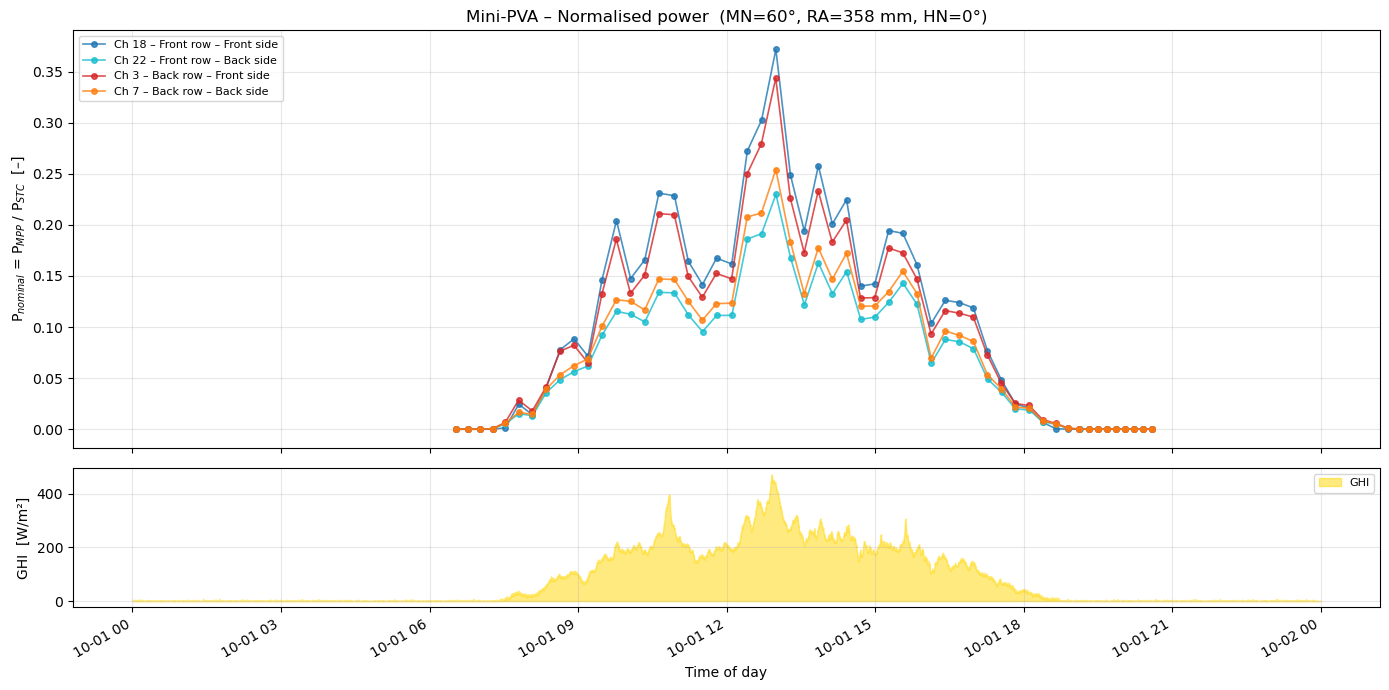

In [7]:
MN_SEL = 60    # module tilt angle [°]
RA_SEL = 358   # row spacing [mm]
HN_SEL = 0     # ground slope [°]

df_plot = df_rel[
    (df_rel['MN'] == MN_SEL) &
    (df_rel['RA'] == RA_SEL) &
    (df_rel['HN'] == HN_SEL)
].copy()

print(f"Configuration: MN={MN_SEL}°, RA={RA_SEL} mm, HN={HN_SEL}° → {len(df_plot)} rows")

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True,
                         gridspec_kw={'height_ratios': [3, 1]})
ax_pv, ax_ghi = axes

for ch, label in RELEVANT_CHANNELS.items():
    grp = df_plot[df_plot['channel'] == ch].sort_values('mes_date')
    ax_pv.plot(grp['mes_date'], grp['Pnominal'],
               marker='o', markersize=4, linewidth=1.2, alpha=0.8,
               color=COLORS[ch], label=f'Ch {ch} – {label}')

ax_pv.set_ylabel('P$_{nominal}$ = P$_{MPP}$ / P$_{STC}$  [–]')
ax_pv.set_title(f'Mini-PVA – Normalised power  '
                f'(MN={MN_SEL}°, RA={RA_SEL} mm, HN={HN_SEL}°)')
ax_pv.legend(fontsize=8, loc='upper left')
ax_pv.grid(True, alpha=0.3)

# Global Horizontal Irradiance as context for the power curve shape
ax_ghi.fill_between(env_data['Timestamp'], env_data['GHI'],
                    alpha=0.5, color='gold', label='GHI')
ax_ghi.set_ylabel('GHI  [W/m²]')
ax_ghi.set_xlabel('Time of day')
ax_ghi.legend(fontsize=8)
ax_ghi.grid(True, alpha=0.3)

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

#### Plot 2 – Bifaciality: front side vs back side

Compares front-side and back-side channels for each module row.
The back side receives diffuse and reflected (albedo) irradiance only.
At this alpine site, snow albedo significantly boosts back-side yield.

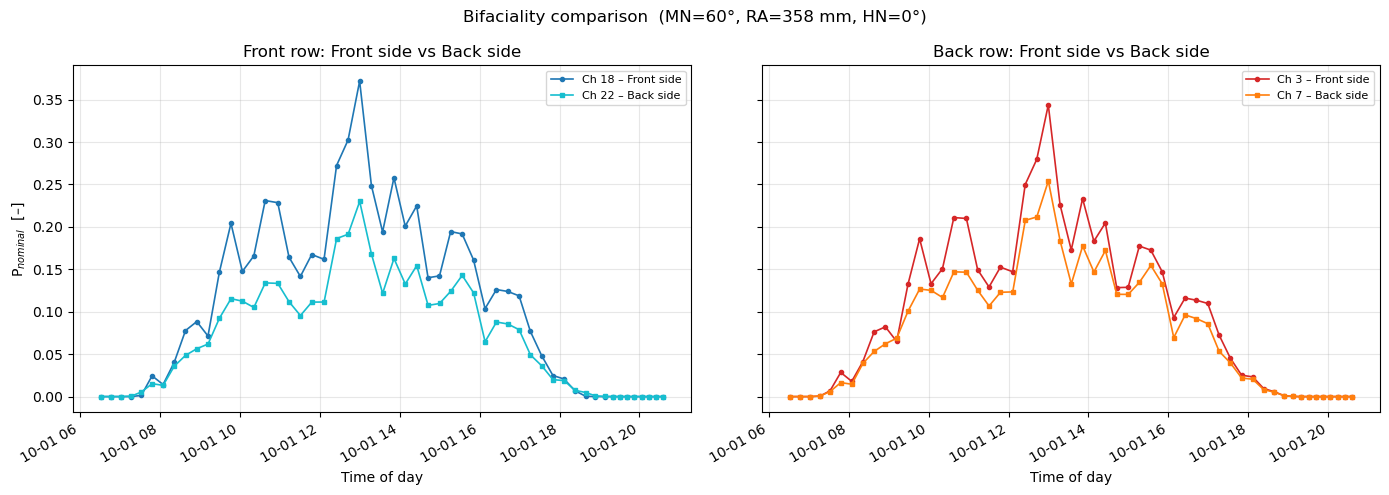

In [8]:
MN_BIF = 60
RA_BIF = 358
HN_BIF = 0

df_bif = df_rel[
    (df_rel['MN'] == MN_BIF) &
    (df_rel['RA'] == RA_BIF) &
    (df_rel['HN'] == HN_BIF)
].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, (ch_front, ch_back), row_name in zip(
    axes, [(18, 22), (3, 7)], ['Front row', 'Back row']
):
    front = df_bif[df_bif['channel'] == ch_front].sort_values('mes_date')
    back  = df_bif[df_bif['channel'] == ch_back].sort_values('mes_date')

    ax.plot(front['mes_date'], front['Pnominal'],
            color=COLORS[ch_front], marker='o', ms=3, lw=1.2,
            label=f'Ch {ch_front} – Front side')
    ax.plot(back['mes_date'], back['Pnominal'],
            color=COLORS[ch_back], marker='s', ms=3, lw=1.2,
            label=f'Ch {ch_back} – Back side')

    ax.set_title(f'{row_name}: Front side vs Back side')
    ax.set_xlabel('Time of day')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel('P$_{nominal}$  [–]')
fig.suptitle(f'Bifaciality comparison  '
             f'(MN={MN_BIF}°, RA={RA_BIF} mm, HN={HN_BIF}°)', fontsize=12)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

#### Plot 3 – Inter-row shading: front row vs back row

Compares front and back module rows for each measurement side.
The back row receives less direct irradiance due to inter-row shading,
especially at low sun angles (morning/evening and winter months).
Uses the same configuration as Plot 2.

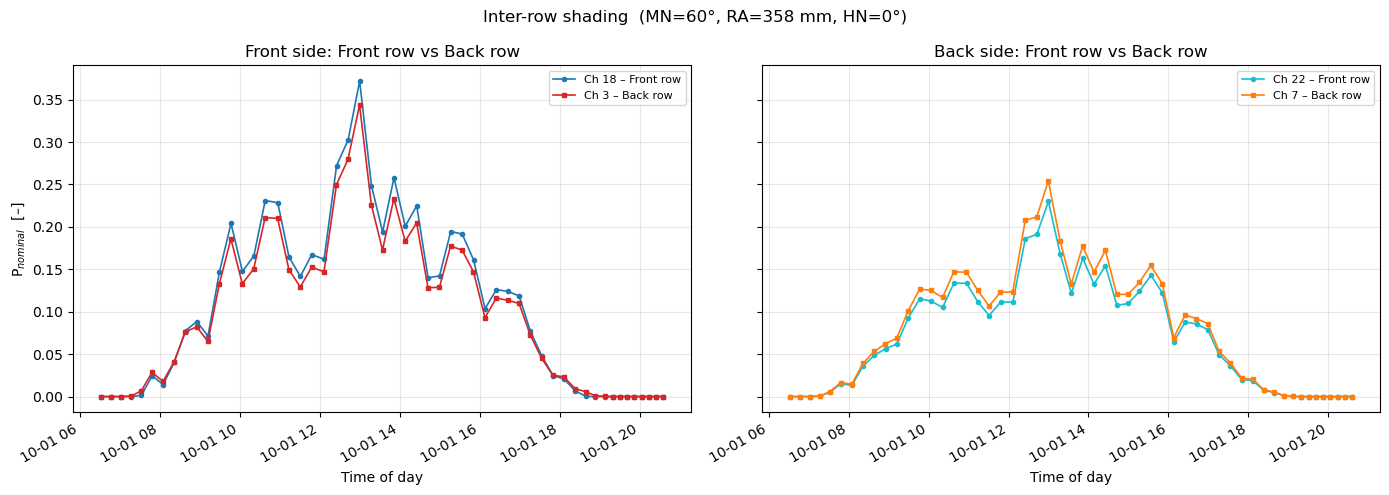

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, (ch_fr, ch_br), side_name in zip(
    axes, [(18, 3), (22, 7)], ['Front side', 'Back side']
):
    fr = df_bif[df_bif['channel'] == ch_fr].sort_values('mes_date')
    br = df_bif[df_bif['channel'] == ch_br].sort_values('mes_date')

    ax.plot(fr['mes_date'], fr['Pnominal'],
            color=COLORS[ch_fr], marker='o', ms=3, lw=1.2,
            label=f'Ch {ch_fr} – Front row')
    ax.plot(br['mes_date'], br['Pnominal'],
            color=COLORS[ch_br], marker='s', ms=3, lw=1.2,
            label=f'Ch {ch_br} – Back row')

    ax.set_title(f'{side_name}: Front row vs Back row')
    ax.set_xlabel('Time of day')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel('P$_{nominal}$  [–]')
fig.suptitle(f'Inter-row shading  '
             f'(MN={MN_BIF}°, RA={RA_BIF} mm, HN={HN_BIF}°)', fontsize=12)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

#### Plot 4 – Effect of module tilt angle (MN)

Channel 18 (front row, front side) at fixed RA=688 mm and HN=0°.
Each line represents a different absolute module tilt angle.
Flatter angles (lower MN) intercept more radiation in winter/alpine conditions.

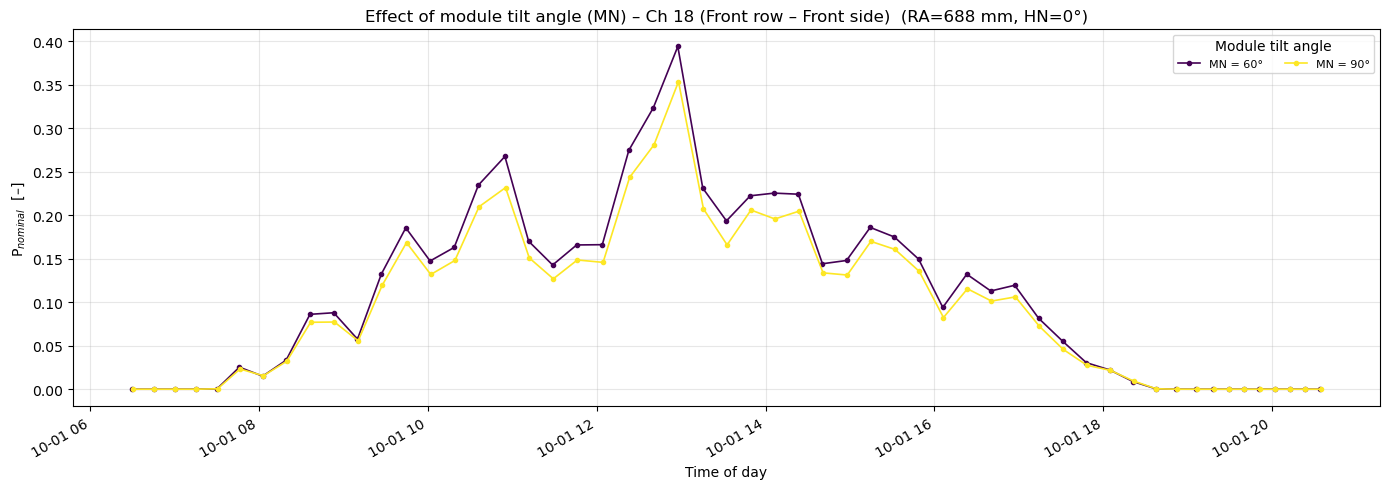

In [10]:
CH_ANGLE     = 18    # front row, front side
RA_SEL_ANGLE = 688   # widest row spacing → minimal shading influence
HN_SEL_ANGLE = 0     # flat ground → isolates MN effect

df_angle = df_rel[
    (df_rel['channel'] == CH_ANGLE) &
    (df_rel['RA'] == RA_SEL_ANGLE) &
    (df_rel['HN'] == HN_SEL_ANGLE)
].copy()

mn_values = sorted(df_angle['MN'].unique())
cmap      = plt.cm.viridis(np.linspace(0, 1, len(mn_values)))

fig, ax = plt.subplots(figsize=(14, 5))

for mn, color in zip(mn_values, cmap):
    grp = df_angle[df_angle['MN'] == mn].sort_values('mes_date')
    ax.plot(grp['mes_date'], grp['Pnominal'],
            marker='o', ms=3, lw=1.2, color=color,
            label=f'MN = {mn}°')

ax.set_ylabel('P$_{nominal}$  [–]')
ax.set_xlabel('Time of day')
ax.set_title(f'Effect of module tilt angle (MN) – '
             f'Ch {CH_ANGLE} ({RELEVANT_CHANNELS[CH_ANGLE]})  '
             f'(RA={RA_SEL_ANGLE} mm, HN={HN_SEL_ANGLE}°)')
ax.legend(fontsize=8, title='Module tilt angle', ncol=4)
ax.grid(True, alpha=0.3)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

#### Plot 5 – Mini-PVA vs Large Installation

The large installation has 6 fixed module groups at known tilt angles (30°–90°).
Mini-PVA measurements at the matching MN value are overlaid for comparison.

**Matching strategy:**
- Monofacial modules (A, B, C, F) → front-side channels only (Ch 18, 3)
- Bifacial modules (D, E) → front + back combined per row: P_bif = P_front + P_back

Mini-PVA channels are measured sequentially (~1 s apart), so timestamps are rounded
to the nearest minute before pairing front and back sides.

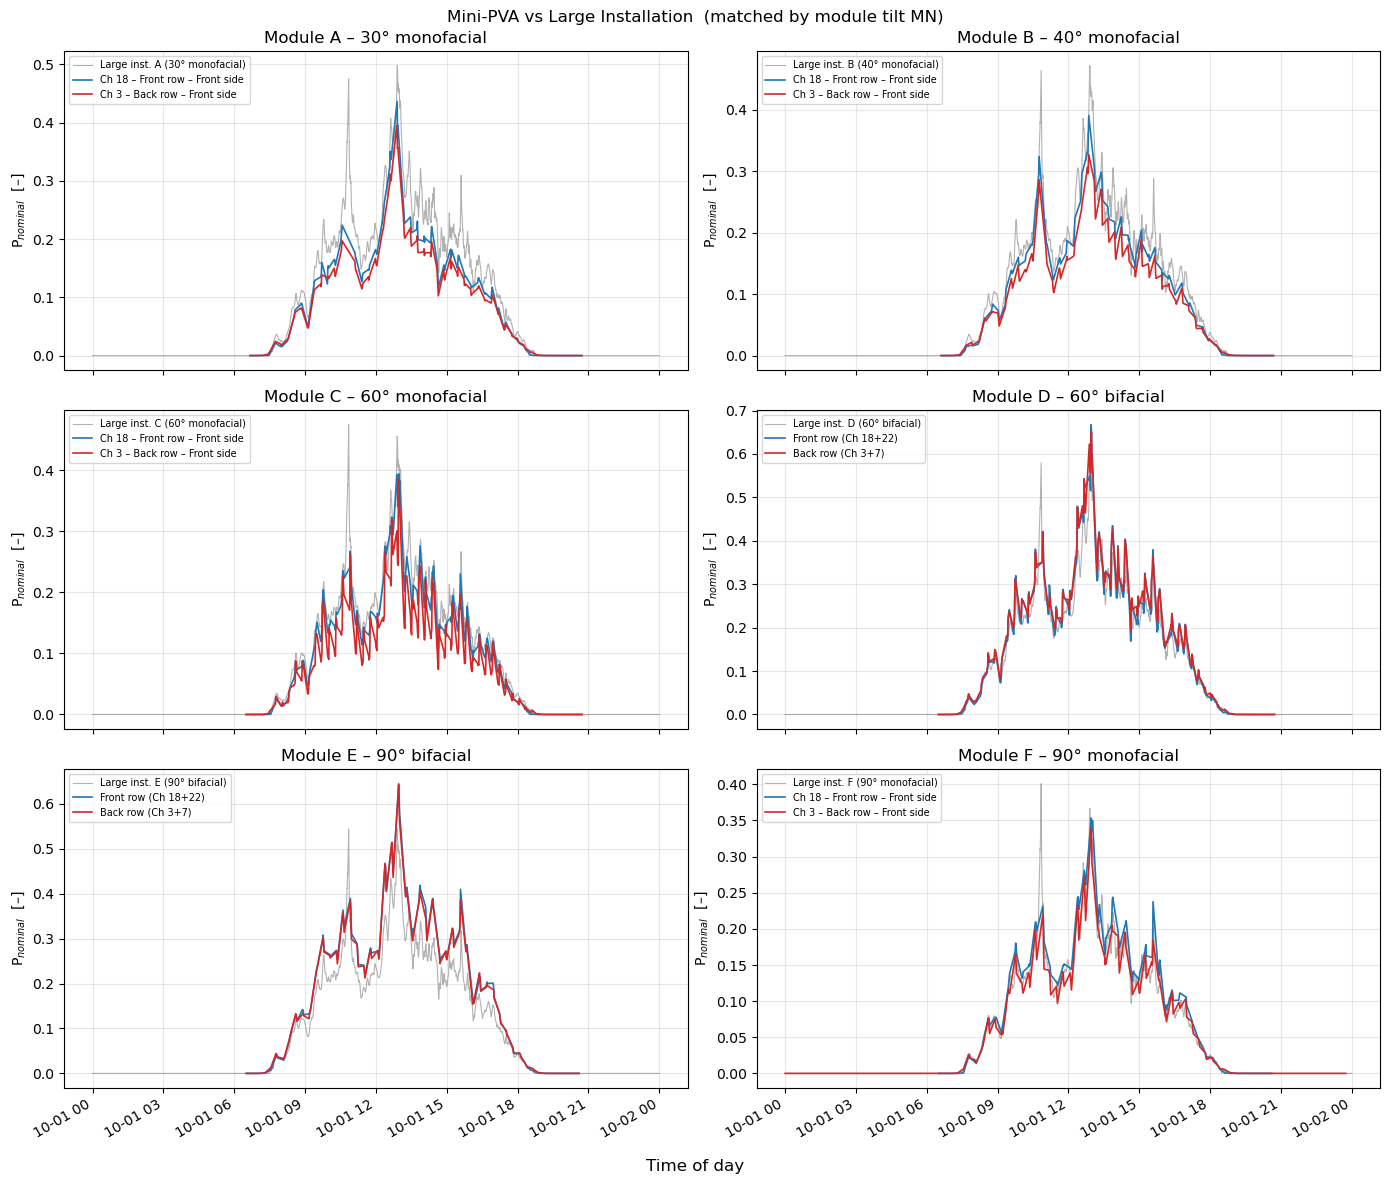

In [11]:
LARGE_MODULES = {
    'A': {'MN': 30, 'type': 'mono', 'desc': '30° monofacial'},
    'B': {'MN': 40, 'type': 'mono', 'desc': '40° monofacial'},
    'C': {'MN': 60, 'type': 'mono', 'desc': '60° monofacial'},
    'D': {'MN': 60, 'type': 'bif',  'desc': '60° bifacial'},
    'E': {'MN': 90, 'type': 'bif',  'desc': '90° bifacial'},
    'F': {'MN': 90, 'type': 'mono', 'desc': '90° monofacial'},
}

large_plot = largeinstallation.set_index('Timestamp')

fig, axes = plt.subplots(3, 2, figsize=(14, 12), sharex=True)
axes = axes.flatten()

for i, (mod, cfg) in enumerate(LARGE_MODULES.items()):
    ax        = axes[i]
    mn_target = cfg['MN']
    mod_type  = cfg['type']

    # Large installation reference (grey background, continuous 10 s data)
    ax.plot(large_plot.index, large_plot[f'Pnorm {mod}'],
            color='grey', linewidth=0.8, alpha=0.6,
            label=f'Large inst. {mod} ({cfg["desc"]})')

    # Mini-PVA data filtered to matching MN (all RA and HN values included)
    df_match = df_rel[df_rel['MN'] == mn_target].copy()

    if mod_type == 'mono':
        # Monofacial: front-side channels only
        for ch in [18, 3]:
            grp = df_match[df_match['channel'] == ch].sort_values('mes_date')
            if len(grp) > 0:
                ax.plot(grp['mes_date'], grp['Pnominal'],
                        color=COLORS[ch], lw=1.2,
                        label=f'Ch {ch} – {RELEVANT_CHANNELS[ch]}')

    else:
        # Bifacial: pair front + back side per row
        # Round to nearest minute to align sequentially measured channels
        df_match['mes_date_round'] = df_match['mes_date'].dt.round('min')

        for (ch_f, ch_b), row_name, clr in zip(
            [(18, 22), (3, 7)],
            ['Front row', 'Back row'],
            ['tab:blue', 'tab:red']
        ):
            front = df_match[df_match['channel'] == ch_f][
                ['mes_date', 'mes_date_round', 'RA', 'HN', 'Pnominal']
            ].rename(columns={'Pnominal': 'P_front'})

            back = df_match[df_match['channel'] == ch_b][
                ['mes_date_round', 'RA', 'HN', 'Pnominal']
            ].rename(columns={'Pnominal': 'P_back'})

            # Merge on rounded timestamp + configuration to align measurements
            merged = front.merge(back, on=['mes_date_round', 'RA', 'HN'], how='inner')
            merged['P_bif'] = merged['P_front'] + merged['P_back']
            merged = merged.sort_values('mes_date')

            if len(merged) > 0:
                ax.plot(merged['mes_date'], merged['P_bif'],
                        color=clr, lw=1.2,
                        label=f'{row_name} (Ch {ch_f}+{ch_b})')

    ax.set_title(f'Module {mod} – {cfg["desc"]}')
    ax.legend(fontsize=7, loc='upper left')
    ax.grid(True, alpha=0.3)
    ax.set_ylabel('P$_{nominal}$  [–]')

fig.supxlabel('Time of day')
fig.suptitle('Mini-PVA vs Large Installation  (matched by module tilt MN)', fontsize=12)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()